# Modul 1 : Histogram, Konvolusi & Operasi Dasar Citra

Nama : Revano Januar Adiguna  Prawira

NIM : F1D02410146

Kelompok : 6

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Import Library
Kode diatas mengimpor beberapa library untuk keperluan pemrosesan citra dan visualisasi. `numpy` digunakan untuk manipulasi array dan perhitungan numerik.`matplotlib.pyplot` berfungsi untuk menampilkan gambar atau grafik. `cv2` untuk merubah warna gambar jadi grey untuk greyscale.

### Menampilkan Citra

Blok kode di atas digunakan untuk membaca dan menampilkan citra yang di grayscale-kan.**`plt.imread(...)`**: Berfungsi untuk membaca file gambar dari direktori `Assets/` dan memuatnya ke dalam memori sebagai matriks *array* pada variabel `citra_1` dan `citra_2`.**`plt.figure(figsize=(10, 5))`**: Membuat sebuah kanvas (figur) baru untuk menampung visualisasi dengan ukuran lebar 10 inci dan tinggi 5 inci agar proporsional.**`plt.subplot(1, 2, 1)`**: Mengatur tata letak (*layout*) kanvas menjadi format *grid* yang terdiri dari 1 baris dan 2 kolom. Angka `1` di akhir menunjukkan bahwa plot selanjutnya akan diletakkan pada posisi pertama (sebelah kiri).**`plt.imshow(citra_1, cmap="gray")`**: Merender matriks `citra_1` menjadi sebuah gambar. Parameter `cmap="gray"` ditambahkan untuk memastikan citra ditampilkan dengan peta warna hitam-putih, yang merupakan standar umum dalam analisis pengolahan citra digital.**`plt.title("Rotasi 180 Derajat")`**: Menyematkan judul teks tepat di atas gambar pertama untuk memberikan konteks pada citra.**`plt.subplot(1, 2, 2)`**: Menunjuk ke posisi *grid* ke-2 (sebelah kanan) untuk memuat gambar selanjutnya.**`plt.tight_layout()`**: Fungsi ini secara otomatis mengoptimalkan jarak (*padding*) antar *subplot* sehingga tampilannya rapi, tidak terpotong, dan elemen teks tidak saling tumpang tindih.**`plt.show()`**: Mengeksekusi seluruh instruksi di atas dan menampilkan hasil akhir visualisasinya ke layar.

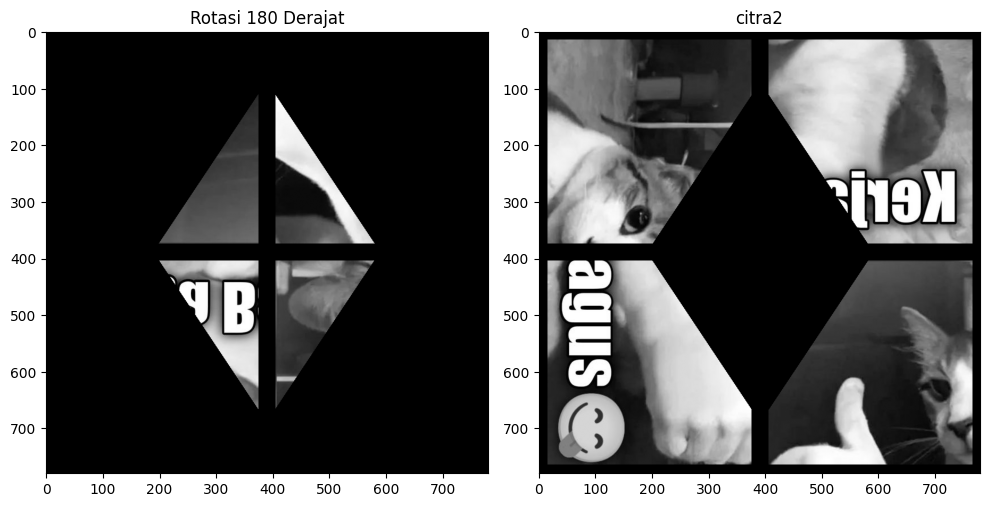

In [5]:
citra_1 = plt.imread('Assets/citra1.PNG')
citra_2 = plt.imread('Assets/citra2.PNG')

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(citra_1, cmap="gray")
plt.title("Rotasi 180 Derajat")

plt.subplot(1, 2, 2)
plt.imshow(citra_2, cmap="gray")
plt.title("citra2")

plt.tight_layout()
plt.show()

### Fungsi Rotasi Citra

Blok kode di atas mengimplementasikan algoritma rotasi citra secara manual pada level piksel tanpa bergantung pada fungsi transformasi instan dari *library* eksternal. Fungsi kustom `fungsi_empat_R` menerima input matriks gambar dan nilai sudut yang langsung dinormalisasi menggunakan operasi modulus 360 agar rentang putarannya selalu valid. Proses utamanya mengandalkan pemetaan ulang koordinat piksel `(i, j)` secara iteratif berdasarkan kondisi sudut kelipatan 90 derajat: rotasi 90° dan 270° membalik dimensi matriks citra dan memindahkan piksel masing-masing ke koordinat `(j, h - 1 - i)` dan `(w - 1 - j, i)`, sementara rotasi 180° mempertahankan dimensi awal dengan mencerminkan posisi piksel ke `(h - 1 - i, w - 1 - j)`. 
Di akhir kode, fungsi ini diaplikasikan untuk memutar matriks `citra_1` sejauh 180 derajat, yang hasilnya kemudian divisualisasikan dalam format *grayscale* menggunakan `matplotlib.pyplot` sebagai bukti keberhasilan pergeseran spasial tersebut.

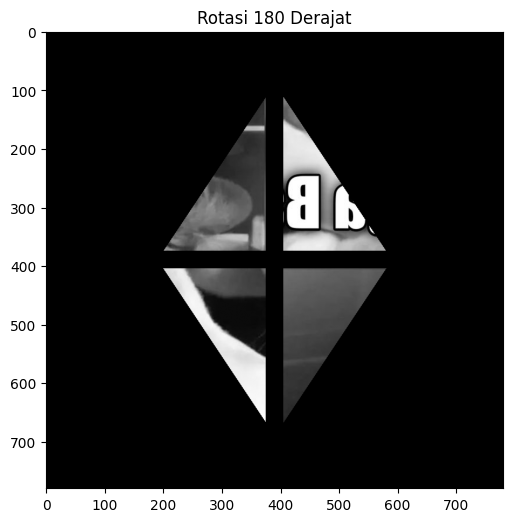

In [6]:
#rotasi
def fungsi_empat_R(gambar, val): 
    h, w = gambar.shape 
    
    val = int(val) % 360  
    if val == 0: return gambar 
    elif val == 90: 
        rot = np.zeros((w, h), dtype=gambar.dtype) 
        for i in range(h): 
            for j in range(w): rot[j, h - 1 - i] = gambar[i, j] 
        return rot 
    elif val == 180: 
        rot = np.zeros_like(gambar, dtype=gambar.dtype) 
        for i in range(h): 
            for j in range(w): 
                rot[h - 1 - i, w - 1 - j] = gambar[i, j] 
        return rot 
    elif val == 270:  
        rot = np.zeros((w, h), dtype=gambar.dtype) 
        for i in range(h): 
            for j in range(w): rot[w - 1 - j, i] = gambar[i, j] 
        return rot 
    return gambar 
#cara penggunaan: hasil = fungsi_empat_r(citra_kamu, nilai_sudut_kelipatan_90) 
citra_1_rotasi = fungsi_empat_R(citra_1, 180)

# Menampilkan hasil
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(citra_1_rotasi, cmap="gray")
plt.title("Rotasi 180 Derajat")

plt.tight_layout()
plt.show()

### Operasi Penjumlahan Citra

Blok kode di atas menjalankan operasi aritmatika dasar pada dua buah citra digital, yaitu operasi penjumlahan matriks.

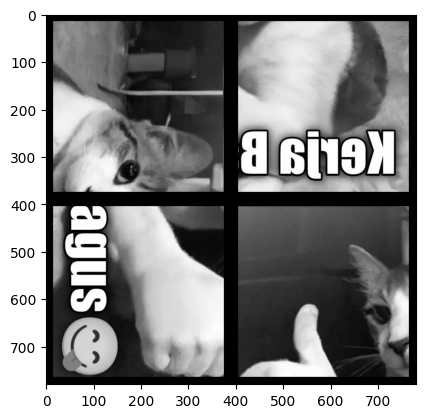

In [7]:
merge = citra_1_rotasi + citra_2
plt.imshow(merge, cmap='gray')
plt.show()

### Slicing

Fokus utama pada tahap ini adalah proses pemotongan 1 citra menjadi empat 4 citra yang berukuran sama. Pemotongan dieksekusi melalui fungsi kustom `fungsi_empat_S` yang mengandalkan teknik pengindeksan *array* bawaan NumPy, di mana parameter `mode` menentukan apakah matriks akan diiris secara horizontal pada sumbu Y (baris) atau vertikal pada sumbu X (kolom). Algoritma pemotongannya bekerja secara bertingkat: pertama, kode menghitung titik tengah dimensi gambar (`mid_h` dan `mid_w`) untuk membelah citra utama secara horizontal menjadi blok bagian atas dan bawah. Setelah itu, masing-masing blok diiris kembali secara vertikal menggunakan titik tengah lebarnya. Proses pembelahan dua tahap ini secara efektif mendekomposisi matriks citra awal menjadi empat potongan region yang presisi, yaitu kiri atas, kanan atas, kiri bawah, dan kanan bawah.

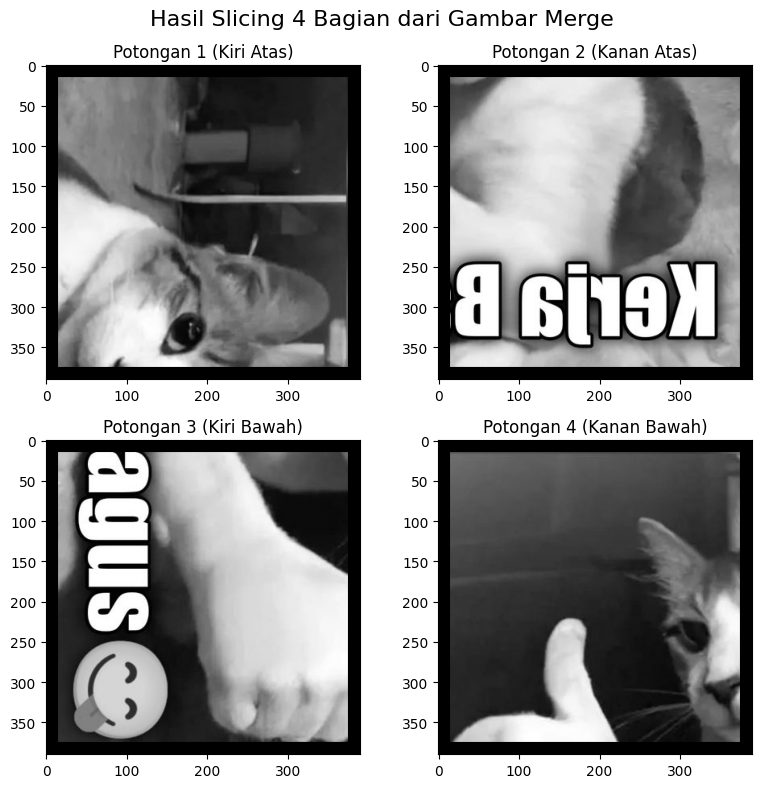

In [8]:
gambar_target = np.clip(merge, 0, 1) if merge.dtype == float else np.clip(merge, 0, 255)
#slice
def fungsi_empat_S(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b] 

h, w = gambar_target.shape[:2]
mid_h = h // 2
mid_w = w // 2

atas = fungsi_empat_S(gambar_target, 0, mid_h, mode='H')
bawah = fungsi_empat_S(gambar_target, mid_h, h, mode='H')

kiri_atas = fungsi_empat_S(atas, 0, mid_w, mode='V')
kanan_atas = fungsi_empat_S(atas, mid_w, w, mode='V')

kiri_bawah = fungsi_empat_S(bawah, 0, mid_w, mode='V')
kanan_bawah = fungsi_empat_S(bawah, mid_w, w, mode='V')

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.imshow(kiri_atas, cmap="gray")
plt.title("Potongan 1 (Kiri Atas)")


plt.subplot(2, 2, 2)
plt.imshow(kanan_atas, cmap="gray")
plt.title("Potongan 2 (Kanan Atas)")


plt.subplot(2, 2, 3)
plt.imshow(kiri_bawah, cmap="gray")
plt.title("Potongan 3 (Kiri Bawah)")


plt.subplot(2, 2, 4)
plt.imshow(kanan_bawah, cmap="gray")
plt.title("Potongan 4 (Kanan Bawah)")


plt.suptitle("Hasil Slicing 4 Bagian dari Gambar Merge", fontsize=16)
plt.tight_layout()
plt.show()

### Flip

Pada tahap ini dilakukan pencerminan (*flip*) citra secara manual pada level piksel melalui fungsi kustom `fungsi_satu`. Algoritma ini bekerja dengan membaca matriks awal secara iteratif, lalu memetakan ulang nilai intensitas pikselnya ke dalam matriks kosong baru berdasarkan parameter `mode` sumbu cermin. Jika mode 'X' dipilih, sistem melakukan pencerminan horizontal dengan memindahkan posisi piksel secara simetris dari kiri ke kanan menggunakan pemetaan koordinat kolom `(i, w - 1 - j)`. Sebaliknya, jika mode 'Y' dipilih, sistem melakukan pencerminan vertikal dari atas ke bawah menggunakan pemetaan koordinat baris `(h - 1 - i, j)`. Pada implementasi akhirnya, potongan gambar `kanan_atas` dan `kanan_bawah` dikenakan operasi pemetaan mode 'X', sehingga menghasilkan proyeksi visual berupa bayangan cermin secara mendatar.

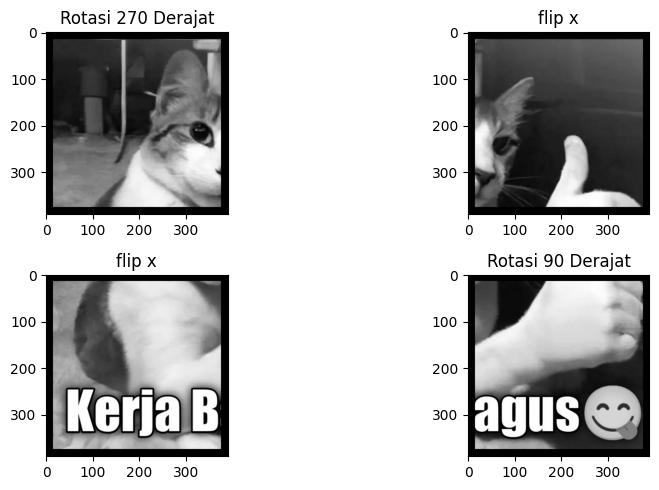

In [9]:
kiri_atas_rotasi = fungsi_empat_R(kiri_atas, 270)
kiri_bawah_rotasi = fungsi_empat_R(kiri_bawah, 270)

#flip
def fungsi_satu(image, mode='X'): 
    h, w = image.shape 
    hasil = np.zeros((h, w), dtype=image.dtype) 
    for i in range(h): 
        for j in range(w): 
            if mode == 'X': 
                hasil[i, j] = image[i, w - 1 - j] 
            elif mode == 'Y': 
                hasil[i, j] = image[h - 1 - i, j] 
    return hasil
 
#cara penggunaan: hasil = fungsi_satu(citra_kamu, 'x_atau_y')

kanan_atas_flip = fungsi_satu(kanan_atas, 'X')
kanan_bawah_flip = fungsi_satu(kanan_bawah, 'X')

plt.figure(figsize=(10, 5))

# Gambar Hasil Rotasi 270 Derajat
plt.subplot(2, 2, 1)
plt.imshow(kiri_atas_rotasi, cmap="gray")
plt.title("Rotasi 270 Derajat")


plt.subplot(2, 2, 2)
plt.imshow(kanan_bawah_flip, cmap="gray")
plt.title("flip x")


plt.subplot(2, 2, 3)
plt.imshow(kanan_atas_flip, cmap="gray")
plt.title("flip x")


plt.subplot(2, 2, 4)
plt.imshow(kiri_bawah_rotasi, cmap="gray")
plt.title("Rotasi 90 Derajat")


plt.tight_layout()
plt.show()

### Translasi

Pada tahap ini dilakukan translasi atau pergeseran citra secara manual pada level piksel melalui fungsi kustom `fungsi_lima`. Algoritma ini bekerja dengan memetakan ulang setiap piksel dari koordinat awal `(i, j)` ke koordinat baru `(new_i, new_j)` dengan menambahkan nilai parameter pergeseran baris vertikal (`geser_baris_y`) dan pergeseran kolom horizontal (`geser_kolom_x`). Untuk mencegah *error* atau distorsi akibat piksel yang terdorong ke luar dimensi gambar, kode ini menerapkan mekanisme pengecekan batas spasial (`if 0 <= new_i < h and 0 <= new_j < w`) sebelum menyalin nilai intensitas piksel ke matriks kanvas baru yang diinisialisasi dengan angka nol (berlatar hitam). Pada eksekusi akhirnya, fungsi ini diaplikasikan untuk menggeser keempat potongan citra sebelumnya ke arah diagonal yang saling berlawanan (menggunakan kombinasi input pergeseran bernilai 15 dan -15), yang kemudian divisualisasikan kembali secara kolektif dalam tata letak matriks visual 2x2.

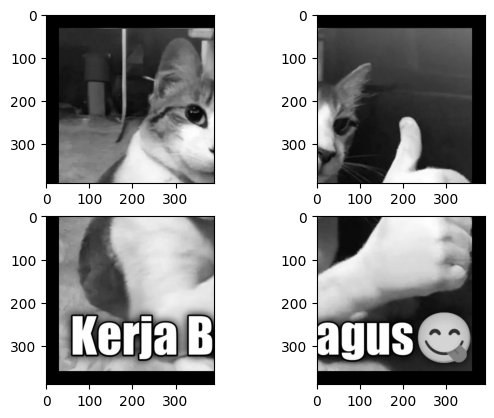

In [10]:
#Translasi
def fungsi_lima(gambar, geser_kolom_x=0, geser_baris_y=0): 
    gambar = np.array(gambar) 
    h, w = gambar.shape 
    hasil = np.zeros((h, w), dtype=gambar.dtype)
    for i in range(h): 
        for j in range(w): 
            new_i = i + geser_baris_y 
            new_j = j + geser_kolom_x 
            if 0 <= new_i < h and 0 <= new_j < w: 
                hasil[new_i, new_j] = gambar[i, j] 
    return hasil 
hasil1_trans = fungsi_lima(kiri_atas_rotasi, 15, 15) 
hasil2_trans = fungsi_lima(kanan_bawah_flip, -15, 15) 
hasil3_trans = fungsi_lima(kanan_atas_flip, 15, -15) 
hasil4_trans = fungsi_lima(kiri_bawah_rotasi, -15, -15) 
plt.subplot(2,2,1)
plt.imshow(hasil1_trans, cmap='gray')
plt.subplot(2,2,2)
plt.imshow(hasil2_trans, cmap='gray')
plt.subplot(2,2,3)
plt.imshow(hasil3_trans, cmap='gray')
plt.subplot(2,2,4)
plt.imshow(hasil4_trans, cmap='gray')

### Dilatasi dan Crop

Pada tahap dilakukan pembesaran skala citra (dilatasi) dan pemotongan tepi (*crop*) secara manual melalui fungsi kustom `fungsi_tiga`. Proses diawali dengan mengekspansi dimensi kanvas matriks menjadi dua kali lipat lebih besar dari ukuran aslinya. Pembesaran skala ini menggunakan metode interpolasi tetangga terdekat (*nearest-neighbor*) yang diaplikasikan secara iteratif, di mana nilai intensitas untuk setiap piksel pada koordinat baru `(y, x)` disalin dari piksel citra asli pada pembagian bulat indeks posisinya `(int(y/2), int(x/2))`, yang secara efektif menduplikasi blok piksel untuk merentangkan gambar. Setelah matriks berhasil diperbesar, tahap selanjutnya adalah membuang margin luar citra berdasarkan empat parameter nilai pangkas (atas, bawah, kiri, dan kanan). Untuk melakukan ini, kode mengkalkulasi batas indeks pemotongan spasial yang baru dengan memanfaatkan fungsi komparasi `max` dan `min` guna memastikan area irisan tetap berada dalam batas dimensi matriks. Pada eksekusi akhirnya, keempat potongan kuadran gambar dikalikan dua ukurannya lalu dipangkas secara simetris sebanyak 30 piksel di keempat sisinya, untuk kemudian divisualisasikan kembali dalam tata letak visual 2x2.

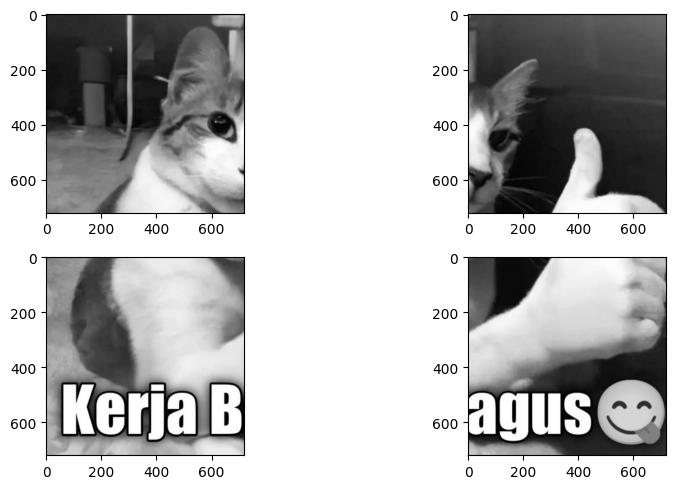

In [11]:
#dilatasi & crop
def fungsi_tiga(image, p1=0, p2=0, p3=0, p4=0): 
    h, w = image.shape 
    # skala 2x lipat 
    dilated = np.zeros((h * 2, w * 2), dtype=image.dtype)
    for y in range(h * 2): 
        for x in range(w * 2): 
            dilated[y][x] = image[int(y / 2)][int(x / 2)] 
    # normalisasi (crop) sisi luar 
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2) 
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4) 
    return dilated[sy:ey, sx:ex] 
#cara penggunaan: hasil = fungsi_tiga(citra_kamu, atas, bawah, kiri, kanan) 

kiri_atasDC = fungsi_tiga(kiri_atas_rotasi, 30, 30, 30, 30)
kanan_atasDC = fungsi_tiga(kanan_atas_flip, 30, 30, 30, 30)
kiri_bawahDC = fungsi_tiga(kiri_bawah_rotasi, 30, 30, 30, 30)
kanan_bawahDC = fungsi_tiga(kanan_bawah_flip, 30, 30, 30, 30)

plt.figure(figsize=(10, 5))

# Gambar Hasil Rotasi 270 Derajat
plt.subplot(2, 2, 1)
plt.imshow(kiri_atasDC, cmap="gray")

plt.subplot(2, 2, 2)
plt.imshow(kanan_bawahDC, cmap="gray")

plt.subplot(2, 2, 3)
plt.imshow(kanan_atasDC, cmap="gray")

plt.subplot(2, 2, 4)
plt.imshow(kiri_bawahDC, cmap="gray")

plt.tight_layout()
plt.show()

### Merge/penggabungan

Pada tahap akhir ini dilakukan proses rekonstruksi atau penyusunan kembali potongan-potongan citra menggunakan teknik konkatenasi matriks spasial. Kode mengimplementasikan fungsi kustom `fungsi_dua_b` untuk penyambungan horizontal (kiri-kanan) dan `fungsi_dua_c` untuk penyambungan vertikal (atas-bawah), yang bekerja dengan cara menginisialisasi matriks kanvas kosong berskala gabungan menggunakan `np.zeros`, lalu menyalin piksel dari masing-masing citra ke dalam blok batas indeks yang bersesuaian. Pada tahap eksekusi, susunan gambar sengaja disilangkan: potongan matriks `kiri_atasDC` dan `kanan_bawahDC` digabungkan secara horizontal menjadi blok `gabungan_atas`, sementara `kanan_atasDC` dan `kiri_bawahDC` digabungkan menjadi blok `gabungan_bawah`. Kedua blok memanjang tersebut kemudian ditumpuk secara vertikal menggunakan `fungsi_dua_c` untuk membentuk satu kesatuan gambar utuh pada variabel `hasil_akhir`. Sebagai langkah penyesuaian akhir, nilai intensitas matriks gabungan ini diskalakan ulang dengan cara dibagi dua, lalu dikonversi secara eksplisit ke dalam tipe data standar citra digital 8-bit (`np.uint8` dengan rentang 0-255) agar gambar dapat dirender dengan baik dan terhindar dari *error* visual saat ditampilkan oleh fungsi *plot*.

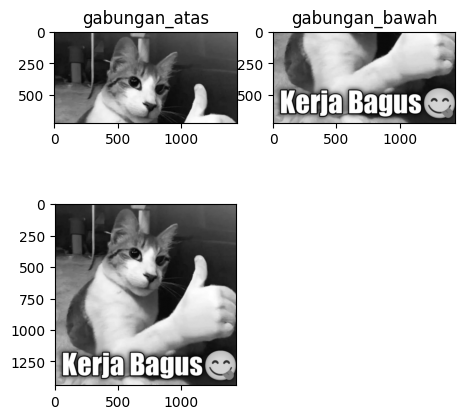

In [12]:
#tipe a: penyatuan ruang (tumpuk/blending) 
def fungsi_dua_a(c1, c2): 
    return c1 + c2 
 
#tipe b: penyatuan sumbu horizontal (kiri-kanan) 
def fungsi_dua_b(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = max(c1.shape[0], c2.shape[0]) 
    lebar = c1.shape[1] + c2.shape[1] 
    
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[0:c2.shape[0], c1.shape[1]:] = c2 
    return hasil 

#tipe c: penyatuan sumbu vertikal (atas-bawah) 
def fungsi_dua_c(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = c1.shape[0] + c2.shape[0] 
    lebar = max(c1.shape[1], c2.shape[1]) 
    
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2 
    return hasil 
#cara penggunaan: hasil = fungsi_dua_b(potongan_kiri, potongan_kanan)

gabungan_atas = fungsi_dua_b(kiri_atasDC, kanan_bawahDC)

gabungan_bawah = fungsi_dua_b(kanan_atasDC, kiri_bawahDC)

hasil_akhir = fungsi_dua_c(gabungan_atas, gabungan_bawah)

hasil_akhir = hasil_akhir / 2
full_image_uint8 = (hasil_akhir * 255).astype(np.uint8)

plt.figure(figsize=(8, 8))

plt.subplot(3, 3, 1)
plt.imshow(gabungan_atas, cmap="gray")
plt.title('gabungan_atas')

plt.subplot(3, 3, 2)
plt.imshow(gabungan_bawah, cmap="gray")
plt.title('gabungan_bawah')

plt.subplot(3, 3, 4)
plt.imshow(full_image_uint8, cmap='gray')


plt.show()

In [13]:
def hitung_histogram(image):
    hist = [0] * 256
    for baris in image:
        for px in baris:
            hist[int(px)] += 1
    return hist

### Fungsi untuk hitung histogram

Proses diawali dengan menginisialisasi sebuah *array* (`hist`) yang berisi 256 elemen bernilai nol, merepresentasikan rentang level keabuan standar pada citra digital 8-bit (0 hingga 255). Algoritma utamanya bekerja menggunakan perulangan bersarang (*nested loop*) untuk menelusuri keseluruhan elemen matriks gambar dari tingkat baris turun hingga ke tingkat piksel individu. Setiap kali nilai intensitas piksel dibaca, nilainya dipastikan bertipe bilangan bulat dan langsung dipetakan sebagai nomor indeks pada *array* histogram, di mana nilai pada indeks tersebut akan ditambahkan satu (`+= 1`). Melalui proses iteratif ini, fungsi secara akumulatif menghitung total kemunculan dari setiap tingkat kecerahan, menghasilkan *array* akhir yang memuat rekam jejak statistik distribusi warna keabuan citra secara utuh.

### Normalisasi

Pada tahap ini diterapannya teknik peningkatan kontras citra (*contrast stretching*) melalui fungsi kustom `normalize` beserta analisis perbandingannya menggunakan grafik histogram. Algoritma normalisasi ini bekerja dengan mencari nilai intensitas piksel paling gelap (`imin`) dan paling terang (`imax`) pada matriks, lalu merentangkan atau memetakan ulang keseluruhan nilai piksel tersebut secara linier agar membentang penuh di rentang standar 0 hingga 255 menggunakan rumus `(image - imin) / (imax - imin) * 255`. Untuk mendemonstrasikan efektivitasnya, citra hasil gabungan sebelumnya direntangkan kembali kontrasnya setelah mengalami pembagian nilai (`// 2`), di mana komputasi sebaran pikselnya direkam menggunakan fungsi `hitung_histogram` sebelum dan sesudah diproses. Perubahan drastis dari rentang dinamis ini kemudian divisualisasikan secara komparatif menggunakan fungsi `plt.bar` dari Matplotlib, menghasilkan dua grafik histogram berdampingan yang membuktikan secara visual bagaimana kelompok nilai piksel yang awalnya sempit (karena kontras rendah) berhasil direnggangkan distribusinya hingga memenuhi seluruh spektrum keabuan yang tersedia.

(0.0, 255.0)

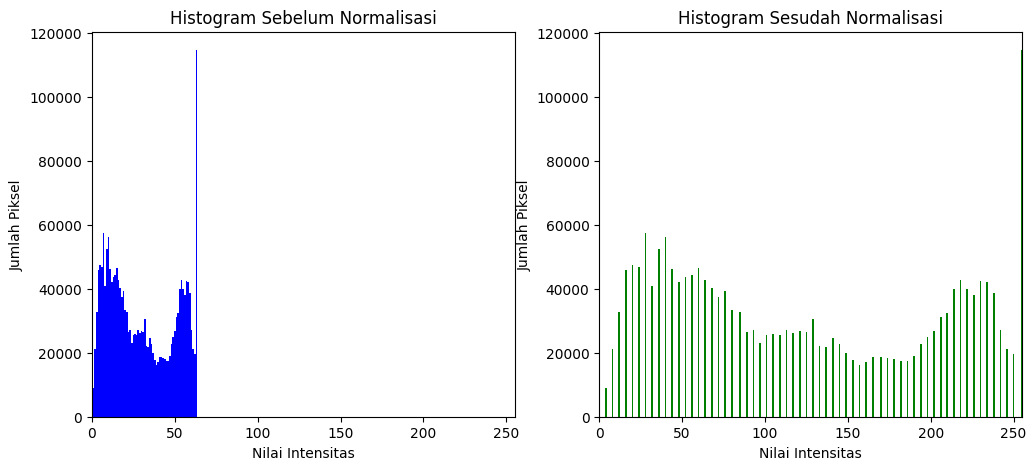

In [14]:
#normalisasi
def normalize(image):
    imin, imax = image.min(), image.max()
    if imax == imin:
        return np.zeros_like(image, dtype=np.uint8) + 128
    norm = (image - imin) / (imax - imin) * 255
    return norm.astype(np.uint8)

hist_awal = hitung_histogram(full_image_uint8 // 2)
normalized_image = normalize(full_image_uint8 // 2)
hist_normal = hitung_histogram(normalized_image)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(range(256), hist_awal, color='blue', width=1)
plt.title('Histogram Sebelum Normalisasi')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])

plt.subplot(1,2,2)
plt.bar(range(256), hist_normal, color='green', width=1)
plt.title('Histogram Sesudah Normalisasi')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])

### Konvolusi kernel

Pada tahap ini adalah implementasi operasi konvolusi dua dimensi secara manual untuk mengekstraksi fitur citra menggunakan matriks *kernel* filter kustom berukuran 4x4. Algoritma dalam fungsi `conv2d_manual` ini diawali dengan tahap *zero padding*, yaitu penambahan bingkai piksel bernilai nol (hitam) di sekeliling gambar asli yang tebalnya disesuaikan dengan dimensi *kernel*, bertujuan untuk mencegah hilangnya informasi citra pada area tepi saat filter digeser. Setelah matriks kanvas disiapkan, proses penyaringan dieksekusi menggunakan perulangan bersarang yang menggeser matriks *kernel* melintasi seluruh titik koordinat piksel layaknya jendela pandang (*sliding window*). Pada setiap titik pergeseran, blok piksel tetangga yang tertutup oleh *kernel* diisolasi, dikalikan secara *element-wise* dengan bobot matriks filter tersebut, lalu dijumlahkan nilai totalnya untuk menghasilkan intensitas piksel baru di titik pusat. Karena perhitungan matematis berbobot negatif ini rentan menghasilkan nilai piksel di luar standar visual matriks, fungsi `np.clip` diaplikasikan di akhir untuk memaksa nilai kembalian masuk ke rentang valid 0 hingga 255 sebelum dikonversi ke format `np.uint8`, memastikan hasil akhirnya dapat dirender dengan sempurna sebagai citra *grayscale*.

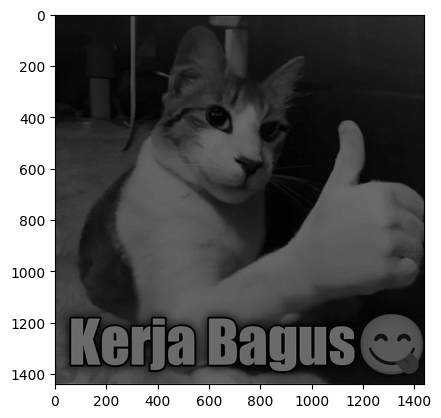

In [15]:
kernel = np.array([
    [-0.1, -0.1, -0.1, -0.1],
    [-0.1,  0.4,  0.4, -0.1],
    [-0.1,  0.4,  0.4, -0.1],
    [-0.1, -0.1, -0.1, -0.1]
])

def conv2d_manual(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh//2, kw//2
    
    # zero padding
    padded = np.zeros((h + 2*pad_h, w + 2*pad_w))
    padded[pad_h:pad_h+h, pad_w:pad_w+w] = image
    
    # hasil konvolusi
    result = np.zeros_like(image, dtype=float)
    
    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            result[i, j] = np.sum(region * kernel)
    
    # clipping ke 0–255
    result = np.clip(result, 0, 255).astype(np.uint8)
    return result

konvo_clip = conv2d_manual(normalized_image, kernel)
plt.imshow(konvo_clip, cmap="gray")

Pada tahap akhir ini kode memanggil kembali fungsi kustom `hitung_histogram` untuk mengekstraksi dan memetakan sebaran nilai level keabuan dari matriks citra hasil konvolusi (`konvo_clip`) ke dalam sebuah *array* berukuran 256 elemen. Rekam jejak statistik ini kemudian diubah menjadi representasi grafik batang (*bar chart*) menggunakan fungsi `plt.bar` dari modul Matplotlib pada kanvas visual berukuran 4x4 inci. Untuk memastikan grafik menampilkan informasi yang akurat dan proporsional, kode menerapkan parameter `width=1` agar antar-batang saling berhimpitan merepresentasikan spektrum yang kontinu, serta menggunakan fungsi `plt.xlim([0, 255])` yang secara tegas membatasi sumbu horizontal koordinat agar terkunci tepat pada rentang standar citra digital 8-bit, sehingga visualisasi akhir yang dirender ke layar benar-benar berfokus pada area persebaran piksel yang valid.

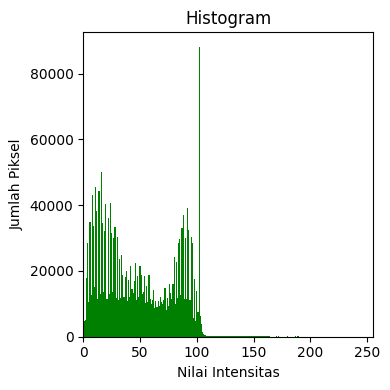

In [16]:
hist_conv = hitung_histogram(konvo_clip)

plt.figure(figsize=(4, 4))
plt.bar(range(256), hist_conv, color='green', width=1)
plt.title('Histogram')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])
plt.tight_layout()
plt.show()

### Analisis Proses

Berdasarkan pengolahan citra yang dilakukan, gambar pada awalnya terlihat gelap dengan grafik histogram yang sempit menumpuk di sisi kiri akibat proses pembagian nilai piksel sebelumnya. Untuk mengatasinya, tahap normalisasi diterapkan guna merentangkan kontras, sehingga gambar yang tadinya redup menjadi jauh lebih terang dan detailnya kembali terlihat. Selanjutnya, gambar diberi bingkai nilai nol di bagian tepi (zero padding) agar ukurannya tidak menyusut saat melewati tahap konvolusi. Proses konvolusi ini sangat penting karena berfungsi layaknya filter untuk menajamkan garis tepi dan memperjelas detail tekstur objek pada gambar. Namun, karena perhitungan konvolusi sering kali menghasilkan angka piksel yang terlalu ekstrem, tahap clipping wajib digunakan untuk memaksa semua nilai kembali ke rentang standar 0 hingga 255 agar tidak muncul bercak cacat pada gambar. Pada akhirnya, bentuk grafik histogram terakhir mencerminkan keberhasilan seluruh proses ini: sebaran warnanya kembali luas dan stabil berkat normalisasi dan clipping, sementara kemunculan detail objek yang tajam merupakan hasil langsung dari filter konvolusi.